# DCT data inspection

Small notebook for first-look inspection of an older DCT scan. Sections mirror the dataset table in `src/Planning`:

1. Raw data — HDF5, `uint16`, `(3600, 2048, 2048)`, optical-distortion corrected
2. Preprocessed data — HDF5, `float32`, moving median + direct-beam handling
3. Segmentation data — HDF5, `uint8`, 3D binary mask
4. Diffraction blobs — HDF5, `float32`, 3D blobs + metadata
5. Preprocessed LoG — TAR of TIFs (partial)

**Set `SCAN_DIR` in the setup cell to point at one scan, then run top-to-bottom.** Each section runs a `peek` first that prints the file's structure — adjust the dataset key names to match what's actually there.

In [9]:
from pathlib import Path
import io, tarfile
import h5py
import hdf5plugin  # noqa: F401 — registers Blosc/Bitshuffle/LZ4 used by ESRF
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [31]:
DATA_ROOT = Path(r"../../data_esrf/mnt")

# Registry of all scans. `main` = primary frame stack (3D, uint16 or float32).
# Optional: `pre` (precomputed float32 preprocessed), `log_tar` (LoG-TIF tar).
# Every folder has segvol.h5 / dataset "segvol" — assumed by default.
DATASETS = {
  "Al":              {"main": "_iris_iris_500_cont.h5",
                      "pre":  "full.h5"},
  "Al_big_grains":   {"main": "Al1050_dct7p5_Al1050_dct7p.h5"},
  "Al_deformed_LoG": {"main": "A2050_as_annealed_DT_W370_0p12_strain_dct3_A2050_as_annealed_DT_W370_0p12_strain_dct.h5",
                      "log_tar": "A2050_as_annealed_DT_W370_0p12_strain_dct3.tar"},
  "Al_small_grains": {"main": "iris_dct_450C_0003_iris_dct_450C.h5"},
  "Cu":              {"main": "copper3_dct_load1_redo_copper3_dct_load1_redo.h5"},
  "IN718_twins":     {"main": "ep_sync_12_dct_7p5_3_ep_sync_12_dct_7p5.h5"},
  "Iron":            {"main": "ind_Iron_dct_load1_z1_ind_Iron_dct_load1_z.h5"},
  "Iron_deformed":   {"main": "pureIron2_dct_2nd_load_z1_pureIron2_dct_2nd_load_z.h5"},
  "Ti7Al":           {"main": "sam_23_dct4_sam_23_dct.h5"},
}

# === SELECT SCAN ===  change this one line, re-run setup, then run sections below
MATERIAL = "Iron"

entry     = DATASETS[MATERIAL]
SCAN_DIR  = DATA_ROOT / MATERIAL
raw_path  = SCAN_DIR / entry["main"]
RAW_KEY   = entry.get("main_key", "instrument/detector_0/data")
PRE_KEY   = entry.get("pre_key",  "image/data")
SEG_KEY   = entry.get("seg_key",  "segvol")

N_HALF          = 10
FRIEDEL_OFFSET  = 3600       # frames = 180° at 0.1°/frame
START           = 340      # side A start; side B = START + FRIEDEL_OFFSET

def peek_h5(path):
  with h5py.File(path, "r") as f:
      print(f"== {path.name} ==")
      def visitor(name, obj):
          if isinstance(obj, h5py.Dataset):
              print(f"DATASET  {name:40s} shape={obj.shape} dtype={obj.dtype}")
          elif isinstance(obj, h5py.Group):
              print(f"GROUP    {name}")
      f.visititems(visitor)

def load_batch_pair(ds, start=START, n=N_HALF, offset=FRIEDEL_OFFSET):
  """Read n frames at `start` and n frames at `start + offset` (180° around).
  Returns (start_a, batch_a, start_b, batch_b)."""
  a = ds[start : min(ds.shape[0], start + n)]
  sb = start + offset
  b = ds[sb : min(ds.shape[0], sb + n)]
  return start, a, sb, b

def image_contrast(frame, low=1, high=99.7, gamma=0.45):
  """Robust display scaling that brightens faint nonzero diffraction points."""
  values = frame[np.isfinite(frame) & (frame > 0)]
  if values.size == 0:
      return {}
  vmin, vmax = np.percentile(values, [low, high])
  if vmax <= vmin:
      vmax = values.max()
  if vmax <= vmin:
      return {}
  return {"norm": mcolors.PowerNorm(gamma=gamma, vmin=vmin, vmax=vmax)}

def show_montage_pair(batch_a, start_a, batch_b, start_b,
                      cmap="gray", suptitle=None, frame_size=6, brighten=True):
  """Display two batches side-by-side as two columns of full-resolution frames."""
  n = max(len(batch_a), len(batch_b))
  fig, axes = plt.subplots(n, 2, figsize=(2 * frame_size, frame_size * n))
  if n == 1:
      axes = axes.reshape(1, 2)
  for col, (batch, s0, side) in enumerate([
      (batch_a, start_a, "+ω"),
      (batch_b, start_b, "+ω+180°"),]):
      for i in range(n):
          ax = axes[i, col]
          if i < len(batch):
              contrast = image_contrast(batch[i]) if brighten else {}
              ax.imshow(batch[i], cmap=cmap, **contrast)
              ax.set_title(f"{side}   ω={s0 + i}", fontsize=11)
          ax.axis("off")
  if suptitle:
      fig.suptitle(suptitle, fontsize=13)
  fig.tight_layout()

print(f"Available scans: {list(DATASETS)}")
print(f"\nSelected: {MATERIAL}  →  {SCAN_DIR}")
print(f"  main: {entry['main']}")
if "pre" in entry:     print(f"  pre:  {entry['pre']}")
if "log_tar" in entry: print(f"  tar:  {entry['log_tar']}")
print()
print(f"Listing {SCAN_DIR}:")
for p in sorted(SCAN_DIR.glob("*")):
    suffix = "/" if p.is_dir() else ""
    size = "—" if p.is_dir() else f"{p.stat().st_size // 1024**2} MB"
    print(f"  {p.name + suffix:80s}  {size}")


Available scans: ['Al', 'Al_big_grains', 'Al_deformed_LoG', 'Al_small_grains', 'Cu', 'IN718_twins', 'Iron', 'Iron_deformed', 'Ti7Al']

Selected: Iron  →  ../../data_esrf/mnt/Iron
  main: ind_Iron_dct_load1_z1_ind_Iron_dct_load1_z.h5

Listing ../../data_esrf/mnt/Iron:
  im_seg/                                                                           —
  ind_Iron_dct_load1_z1_darkend.h5                                                  66 MB
  ind_Iron_dct_load1_z1_ind_Iron_dct_load1_z.h5                                     21197 MB
  segvol.h5                                                                         460 MB


## 1. Raw data
`uint16`, `(T=3600, H=2048, W=2048)`, optical-distortion corrected.

In [ ]:
peek_h5(raw_path)

with h5py.File(raw_path, "r") as f:
  raw = f[RAW_KEY]
  print(f"full shape={raw.shape} dtype={raw.dtype}")
  sa, ba, sb, bb = load_batch_pair(raw)
  print(f"side A: frames [{sa}..{sa + len(ba) - 1}]  |  "
        f"side B: frames [{sb}..{sb + len(bb) - 1}]  "
        f"({(ba.nbytes + bb.nbytes) // 1024**2} MB in RAM)")

show_montage_pair(ba, sa, bb, sb,
                  suptitle=f"{MATERIAL} raw ({raw_path.name}) — Friedel-offset pair around ω={sa}")


== ind_Iron_dct_load1_z1_ind_Iron_dct_load1_z.h5 ==
GROUP    instrument
GROUP    instrument/detector_0
DATASET  instrument/detector_0/data               shape=(7200, 2048, 2048) dtype=uint16
GROUP    instrument/detector_0/others
DATASET  instrument/detector_0/others/Date        shape=(7200,) dtype=|S11
GROUP    instrument/file
DATASET  instrument/file/scan_header              shape=(7200,) dtype=|S183
GROUP    measurement
GROUP    measurement/image_0
GROUP    measurement/image_0/info
GROUP    measurement/image_0/info/others
DATASET  measurement/image_0/info/others/Date     shape=(7200,) dtype=|S11
DATASET  names                                    shape=(7200,) dtype=object
full shape=(7200, 2048, 2048) dtype=uint16
side A: frames [340..349]  |  side B: frames [3940..3949]  (160 MB in RAM)


## 2. Preprocessed data
`float32`, same shape as raw. Moving median + special direct-beam handling applied upstream.

In [22]:
if "pre" not in entry:
  print(f"No preprocessed file registered for {MATERIAL}. Skipping.")
else:
  pre_path = SCAN_DIR / entry["pre"]
  peek_h5(pre_path)

  with h5py.File(pre_path, "r") as f:
      pre = f[PRE_KEY]
      print(f"full shape={pre.shape} dtype={pre.dtype}")
      sa, ba, sb, bb = load_batch_pair(pre)
      print(f"side A: frames [{sa}..{sa + len(ba) - 1}]  |  "
            f"side B: frames [{sb}..{sb + len(bb) - 1}]  "
            f"({(ba.nbytes + bb.nbytes) // 1024**2} MB in RAM)")

  show_montage_pair(ba, sa, bb, sb, cmap="magma",
                    suptitle=f"{MATERIAL} preprocessed ({pre_path.name}) — Friedel-offset pair around ω={sa}")


No preprocessed file registered for Iron. Skipping.


## 3. Segmentation mask
`uint8`, same shape. Adaptive-threshold 3D binary mask.

In [8]:
seg_path = SCAN_DIR / "segvol.h5"   # labeled segmentation (uint16, label IDs not binary)
peek_h5(seg_path)

with h5py.File(seg_path, "r") as f:
  seg = f[SEG_KEY]
  print(f"full shape={seg.shape} dtype={seg.dtype}")
  sa, ba, sb, bb = load_batch_pair(seg)
  n_labels_a = len(np.unique(ba)) - 1   # exclude background 0
  n_labels_b = len(np.unique(bb)) - 1
  print(f"side A: frames [{sa}..{sa + len(ba) - 1}]  {n_labels_a} unique label(s)  |  "
        f"side B: frames [{sb}..{sb + len(bb) - 1}]  {n_labels_b} unique label(s)  "
        f"({(ba.nbytes + bb.nbytes) // 1024**2} MB in RAM)")

show_montage_pair(ba, sa, bb, sb, cmap="tab20",
                  suptitle=f"{MATERIAL} segmentation labels — Friedel-offset pair around ω={sa}")


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '../../data_esrf/Ti7Al/segvol.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

## 4. Diffraction blobs
`float32`, 3D blobs + per-blob metadata. Exact schema unknown — this cell prints whatever is there.

In [ ]:
blobs_path = SCAN_DIR / "blobs.h5"   # TODO: adjust filename
peek_h5(blobs_path)

with h5py.File(blobs_path, "r") as f:
    for name in f.keys():
        obj = f[name]
        if isinstance(obj, h5py.Dataset):
            print(f"\n{name}: shape={obj.shape} dtype={obj.dtype}")
            if obj.size > 0:
                head = obj[: min(5, obj.shape[0])]
                print(f"  first {len(head)} record(s):\n  {head}")
        elif isinstance(obj, h5py.Group):
            print(f"\n[group] {name}: {list(obj.keys())}")

## 5. Preprocessed LoG TIFs (TAR, partial)
Laplacian-of-Gaussian edge maps as a tarball of TIFs. Only partially complete — some frames may be missing.

7200 .tif files found in img_seg/
proj1600.tif: shape=(2048, 2048), min=0, max=5830
proj5200.tif: shape=(2048, 2048), min=0, max=5802
proj1601.tif: shape=(2048, 2048), min=0, max=5788
proj5201.tif: shape=(2048, 2048), min=0, max=6337
proj1602.tif: shape=(2048, 2048), min=0, max=4180
proj5202.tif: shape=(2048, 2048), min=0, max=4078
proj1603.tif: shape=(2048, 2048), min=0, max=3173
proj5203.tif: shape=(2048, 2048), min=0, max=2872
proj1604.tif: shape=(2048, 2048), min=0, max=3170
proj5204.tif: shape=(2048, 2048), min=0, max=2712
proj1605.tif: shape=(2048, 2048), min=0, max=3381
proj5205.tif: shape=(2048, 2048), min=0, max=3018
proj1606.tif: shape=(2048, 2048), min=0, max=3466
proj5206.tif: shape=(2048, 2048), min=0, max=2977
proj1607.tif: shape=(2048, 2048), min=0, max=3695
proj5207.tif: shape=(2048, 2048), min=0, max=3147
proj1608.tif: shape=(2048, 2048), min=0, max=3282
proj5208.tif: shape=(2048, 2048), min=0, max=2793
proj1609.tif: shape=(2048, 2048), min=0, max=3129
proj5209.tif: sh

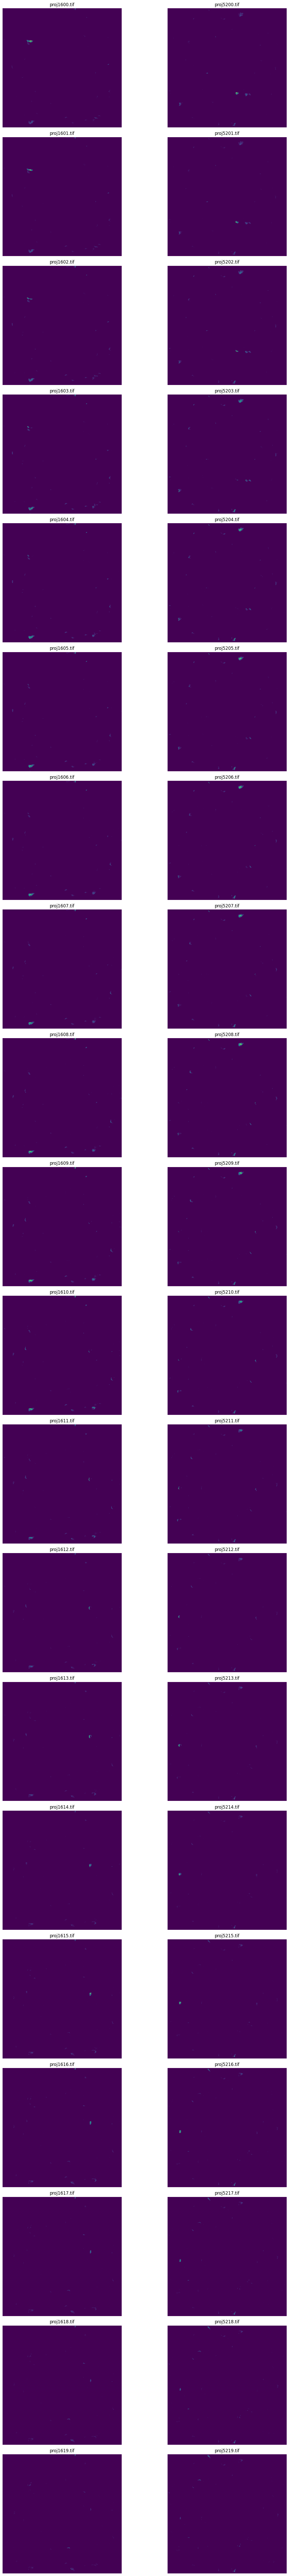

In [25]:
img_seg_path = SCAN_DIR / "im_seg" 

from PIL import Image  # pip install Pillow if missing

# Find all .tif files
tif_files = sorted(img_seg_path.glob("*.tif"))
print(f"{len(tif_files)} .tif files found in img_seg/")

# First 5 and comparison range
first_indices = range(1600, 1620)        # 0001–0006
compare_indices = range(5200, 5220)  # 0180–0184

fig, axes = plt.subplots(20, 2, figsize=(15, 100))

for row, (i1, i2) in enumerate(zip(first_indices, compare_indices)):
    
    # Build filenames
    p1 = img_seg_path / f"proj{i1:04d}.tif"
    p2 = img_seg_path / f"proj{i2:04d}.tif"

    # Load images
    img1 = np.array(Image.open(p1))
    img2 = np.array(Image.open(p2))

    print(f"{p1.name}: shape={img1.shape}, min={img1.min()}, max={img1.max()}")
    print(f"{p2.name}: shape={img2.shape}, min={img2.min()}, max={img2.max()}")

    # Left column
    axes[row, 0].imshow(img1, cmap="viridis")
    axes[row, 0].set_title(p1.name)
    axes[row, 0].axis("off")

    # Right column (mirrored horizontally)
    axes[row, 1].imshow(np.fliplr(img2), cmap="viridis")
    axes[row, 1].set_title(p2.name)
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()


## Frame 1 comparison across all datasets
One raw frame per dataset, saved as a PDF. This does not use Friedel pairs.


In [ ]:
DATA_ROOT_CANDIDATES = [DATA_ROOT, Path(r"../../data_esrf")]
comparison_root = next((p for p in DATA_ROOT_CANDIDATES if (p / "Al").exists()), DATA_ROOT)
FRAME_INDEX = 0  # frame 1 in 1-based naming
OUT_PDF = Path("dataset_frame1_comparison.pdf")

frames = []
for material, dataset_entry in DATASETS.items():
    path = comparison_root / material / dataset_entry["main"]
    key = dataset_entry.get("main_key", RAW_KEY)
    try:
        with h5py.File(path, "r") as f:
            frame = f[key][FRAME_INDEX]
        frames.append((material, frame, None))
        print(f"loaded {material}: {frame.shape} {frame.dtype}")
    except Exception as exc:
        frames.append((material, None, exc))
        print(f"skipped {material}: {exc}")

cols = 3
rows = int(np.ceil(len(frames) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 6), squeeze=False)

for ax, (material, frame, error) in zip(axes.ravel(), frames):
    ax.axis("off")
    if frame is None:
        ax.text(0.5, 0.5, f"{material}\nmissing/unreadable", ha="center", va="center", fontsize=11)
    else:
        contrast = image_contrast(frame)
        if material not in {"Al", "Al_small_grains"}:
            contrast = image_contrast(frame, low=0.2, high=99.2, gamma=0.28)
        ax.imshow(frame, cmap="gray", **contrast)
        ax.set_title(f"{material}\nframe 1", fontsize=12, pad=10)

for ax in axes.ravel()[len(frames):]:
    ax.axis("off")

fig.suptitle("Frame 1 comparison across datasets", fontsize=16, y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.95], h_pad=2.0)
fig.savefig(OUT_PDF, format="pdf", bbox_inches="tight")
plt.show()
print(f"saved {OUT_PDF.resolve()}")


---
Once the filenames and HDF5 keys are confirmed for one scan, generalise by looping `(material, scan)` over `DATA_ROOT.glob("*/*")`.